<a href="https://colab.research.google.com/github/peremartra/Rearchitecting-LLMs/blob/main/CH07/CH07_NB02_QLoRA_QDoRA_L4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<table style="width:100%; border:none; background:none;">
  <tr style="border:none;">
    <td style="border:none; vertical-align:middle; text-align:left; width: 120px;">
      <a href="https://hubs.la/Q040tvsK0"><img src="https://raw.githubusercontent.com/peremartra/Rearchitecting-LLMs/main/Images/cover.png" width="100px" style="border-radius: 4px;"></a>
    </td>
    <td style="border:none; vertical-align:middle; text-align:left;">
      <p style="margin: 0; font-size: 14px;">
        Supplementary code for the <a href="https://hubs.la/Q040tvsK0">Rearchitecting LLMs</a> book by <a href="https://github.com/peremartra">Pere Martra</a>.<br>
        <br>
        Code repository: <a href="https://github.com/peremartra/Rearchitecting-LLMs">https://github.com/peremartra/Rearchitecting-LLMs</a>
      </p>
    </td>
  </tr>
</table>

#Rearchitecting LLMs
## Structural techniques for efficient models


### Chapter 7: Specialization Tuning.

[![LinkedIn](https://img.shields.io/badge/LinkedIn-0077B5?style=flat&logo=linkedin&logoColor=white)](https://www.linkedin.com/in/pere-martra/) [![GitHub](https://img.shields.io/badge/GitHub-100000?style=flat&logo=github&logoColor=white)](https://github.com/peremartra) [![X](https://img.shields.io/badge/X-000000?style=flat&logo=x&logoColor=white)](https://x.com/PereMartra) [![Hugging Face](https://img.shields.io/badge/🤗%20Hugging%20Face-blue)](https://huggingface.co/oopere)

_____
Colab Environment: GPU L4

Models:
* HuggingFaceTB/SmolLM2-1.7B-Instruct
_____

In this notebook, we test two approaches to adapt our model to a specific task: QDoRA and QLoRA.

We study the results of both training processes and compare them with the base model.

# Setting up the notebook

In [ ]:
# We pin versions to ensure reproducibility across different Colab sessions.
# bitsandbytes handles 4-bit quantization, peft provides LoRA and DoRA adapters,
# and trl gives us the SFTTrainer that simplifies the fine-tuning loop.
# lm-eval runs standard benchmarks.
!pip install -q \
    transformers==5.0.0 \
    datasets==4.0.0 \
    peft==0.18.0 \
    trl==0.28.0 \
    bitsandbytes==0.49.2 \
    accelerate==1.12.0 \
    lm-eval \
    langdetect \
    optipfair \
    codecarbon

In [ ]:
import json
import torch
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
)
from peft import LoraConfig, get_peft_model, TaskType
from trl import SFTTrainer, SFTConfig

In [ ]:
# The helper functions used in previous chapters are grouped in the utils.py file.
# We download it from the repository so the notebook is self-contained on Colab.
!wget -q https://raw.githubusercontent.com/peremartra/Rearchitecting-LLMs/main/utils.py

import os
if os.path.exists('utils.py'):
    print("✅ utils.py downloaded successfully")
else:
    print("❌ Failed to download utils.py")

from utils import (
    model_evaluation,  # Benchmark evaluation with lm-eval
    clear_gpu_cache,
)

✅ utils.py downloaded successfully


In [ ]:
# Centralizing all configuration here makes it easy to experiment.
# If you want to test with a smaller subset later, just change TRAIN_SUBSET_SIZE.
MODEL_NAME      = "HuggingFaceTB/SmolLM2-1.7B-Instruct" #"meta-llama/Llama-3.2-1B-Instruct" #"google/gemma-3-4b-it" #"Qwen/Qwen3-1.7B"
DATASET_NAME    = "oopere/clinical-ner-qdora"

LORA_RANK       = 16
LORA_ALPHA      = 32
LORA_DROPOUT    = 0.05
TRAIN_EPOCHS    = 3
LEARNING_RATE   = 2e-4

DORA_RANK       = 8
DORA_ALPHA      = 16
DORA_EPOCHS     = 3
DORA_LR         = 1e-4

BATCH_SIZE      = 8
MAX_SEQ_LENGTH  = 512

# Benchmarks: evaluated on each model variant to measure general knowledge retention
BENCHMARK_TASKS = [
    "arc_easy",
    "winogrande",
    "hellaswag",
    "lambada_openai",
    "piqa"
]
BENCHMARK_LIMIT = 500

# Set to True to run lm-eval benchmarks on each model variant.
# Benchmarks add significant runtime; keep False to skip and only evaluate
# schema compliance.
EXECUTE_BENCHMARKS = True

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
print(f"GPU memory available: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


Device: cuda
GPU memory available: 23.7 GB


## Load model & Dataset

In [ ]:
dataset = load_dataset(DATASET_NAME)

# Quick overview of what we're working with
print(f"Train samples : {len(dataset['train'])}")
print(f"Test samples  : {len(dataset['test'])}")
print()

# Distribution across the five clinical note categories
train_df = dataset["train"].to_pandas()
print("Category distribution (train):")
print(train_df["category"].value_counts().to_string())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/102k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/17.9k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/360 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/40 [00:00<?, ? examples/s]

Train samples : 360
Test samples  : 40

Category distribution (train):
category
clean            92
abbreviations    74
implicit         73
typos            63
irrelevant       58


In [ ]:
# Before training anything, it's worth understanding the diversity of the dataset.
# These five categories are designed to force generalization: the model cannot
# memorize patterns, it must learn the extraction logic across different clinical styles.

for category in ["clean", "abbreviations", "implicit", "typos", "irrelevant"]:
    sample = train_df[train_df["category"] == category].iloc[0]
    print(f"\n{'='*60}")
    print(f"CATEGORY: {category.upper()}")
    print(f"{'='*60}")
    print(f"NOTE:\n{sample['note']}")
    print(f"\nLABEL:\n{json.dumps(sample['label'], indent=2)}")


CATEGORY: CLEAN
NOTE:
HPI: 42-year-old male presents with a 4-day history of worsening non-productive cough, malaise, and subjective fevers. He reports mild shortness of breath upon exertion but denies chest pain or hemoptysis. Physical exam reveals a patient in no acute distress. Vitals: Temp 101.4 F, HR 88 bpm, BP 128/84 mmHg. Lung auscultation shows decreased breath sounds in the right lower lobe. Assessment: Community-acquired pneumonia. Plan: Start Azithromycin 500 mg daily for 5 days. Patient advised to increase fluid intake and follow up in one week.

LABEL:
"{\"patient_age\": 42, \"symptoms\": [\"cough\", \"malaise\", \"fever\", \"shortness of breath\"], \"vital_signs\": {\"temperature\": 101.4, \"heart_rate\": 88, \"blood_pressure\": \"128/84\"}, \"medications\": [{\"name\": \"Azithromycin\", \"dose\": \"500 mg\", \"frequency\": \"daily\"}], \"duration_days\": 4}"

CATEGORY: ABBREVIATIONS
NOTE:
Pt is a 65 yo M who presents to the ED c/o SOB and DOE for the past 4 days. Hx of 

In [ ]:
# NF4 (Normal Float 4) is the quantization format designed specifically for
# neural network weights. It preserves more information than standard int4
# by using a distribution-aware encoding.
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,        # Quantize the quantization constants too
)

print(f"Loading {MODEL_NAME}...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
)

print(f"Model loaded.")
print(f"GPU memory used: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

Loading HuggingFaceTB/SmolLM2-1.7B-Instruct...


config.json:   0%|          | 0.00/908 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/218 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

Model loaded.
GPU memory used: 1.03 GB


## Creating response schema

In [ ]:
REQUIRED_SCHEMA = {
    "patient_age":  (int, type(None)),
    "symptoms":     list,
    "vital_signs":  dict,
    "medications":  list,
    "duration_days": (int, type(None)),
}

VITAL_SIGNS_KEYS = {"temperature", "heart_rate", "blood_pressure"}

def check_schema_compliance(response_text: str) -> dict:
    """
    Evaluates whether a model response is a valid, schema-compliant JSON.
    Returns a dict with:
      - is_valid_json    : bool
      - matches_schema   : bool
      - failure_reason   : str or None
    """
    # Step 1: strip any accidental markdown fences the model might add
    cleaned = response_text.strip().removeprefix("```json").removesuffix("```").strip()

    # Step 2: try to parse as JSON
    try:
        parsed = json.loads(cleaned)
    except json.JSONDecodeError as e:
        return {
            "is_valid_json":  False,
            "matches_schema": False,
            "failure_reason": f"JSON parse error: {e}",
        }

    # Step 3: check top-level keys and types
    for key, expected_type in REQUIRED_SCHEMA.items():
        if key not in parsed:
            return {
                "is_valid_json":  True,
                "matches_schema": False,
                "failure_reason": f"Missing key: '{key}'",
            }
        if not isinstance(parsed[key], expected_type):
            return {
                "is_valid_json":  True,
                "matches_schema": False,
                "failure_reason": f"Wrong type for '{key}': "
                                  f"got {type(parsed[key]).__name__}",
            }

    # Step 4: check vital_signs sub-keys
    for vk in VITAL_SIGNS_KEYS:
        if vk not in parsed["vital_signs"]:
            return {
                "is_valid_json":  True,
                "matches_schema": False,
                "failure_reason": f"Missing vital_signs key: '{vk}'",
            }

    return {
        "is_valid_json":  True,
        "matches_schema": True,
        "failure_reason": None,
    }

In [ ]:
# A well-formed response — should pass both checks
good_response = json.dumps({
    "patient_age": 45,
    "symptoms": ["dry cough", "fever"],
    "vital_signs": {"temperature": 38.5, "heart_rate": 98, "blood_pressure": "120/80"},
    "medications": [{"name": "paracetamol", "dose": "500mg", "frequency": "every 8h"}],
    "duration_days": 3
})

# A response missing vital_signs sub-key — should fail schema
bad_response = json.dumps({
    "patient_age": 45,
    "symptoms": ["dry cough"],
    "vital_signs": {"temperature": 38.5},   # missing heart_rate and blood_pressure
    "medications": [],
    "duration_days": 3
})

print("Good response:", check_schema_compliance(good_response))
print("Bad response :", check_schema_compliance(bad_response))


Good response: {'is_valid_json': True, 'matches_schema': True, 'failure_reason': None}
Bad response : {'is_valid_json': True, 'matches_schema': False, 'failure_reason': "Missing vital_signs key: 'blood_pressure'"}


# Testing Prompts

In [ ]:
# The minimal prompt is what we aim for after fine-tuning:
# a two-word instruction that works because the model has internalized the contract.
MINIMAL_PROMPT = "Extract:"

# The strict prompt is what we need today, without fine-tuning.
# It works — but it requires 15 lines of careful instructions.
# Change one word, and the contract breaks.
STRICT_PROMPT = """You are an automated medical data extraction system.
Your only task is to extract clinical information into a strict JSON format.
Use EXACTLY this schema:
{
  "patient_age": int or null,
  "symptoms": [list of normalized strings],
  "vital_signs": {
    "temperature": float or null,
    "heart_rate": int or null,
    "blood_pressure": string or null
  },
  "medications": [
    {"name": string, "dose": string, "frequency": string}
  ],
  "duration_days": int or null
}
Respond ONLY with the raw JSON. No markdown, no explanation, no extra text."""

In [ ]:
def run_inference(note: str, system_prompt: str, enable_thinking: bool = False) -> str:
    """
    Runs inference on a single clinical note.
    Single-sample inference avoids padding alignment issues on decoder-only models.
    """
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user",   "content": note},
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=enable_thinking,
    )

    inputs = tokenizer([text], return_tensors="pt").to(model.device)

    with torch.inference_mode():     # Faster than torch.no_grad() for inference
        output_ids = model.generate(
            **inputs,
            max_new_tokens=256,      # JSON output never needs more than this
            do_sample=False,
        )

    new_tokens = output_ids[0][len(inputs.input_ids[0]):]
    return tokenizer.decode(new_tokens, skip_special_tokens=True)

In [ ]:
from pyarrow import null
def evaluate_on_test_set(model_fn, system_prompt: str, run_label: str) -> pd.DataFrame:
    """
    Runs inference over the full test split and evaluates schema compliance.
    """
    results = []

    # TEST_SAMPLES: set to None to evaluate the full test set
    TEST_SAMPLES = None

    samples = list(dataset["test"])
    if TEST_SAMPLES:
        samples = samples[:TEST_SAMPLES]

    for sample in samples:
        response   = model_fn(sample["note"], system_prompt)
        compliance = check_schema_compliance(response)
        results.append({
            "category":        sample["category"],
            "model":           run_label,
            "is_valid_json":   compliance["is_valid_json"],
            "matches_schema":  compliance["matches_schema"],
            "failure_reason":  compliance["failure_reason"],
        })

    return pd.DataFrame(results)

In [ ]:
# This is what production prompt engineering looks like without fine-tuning.
# The strict prompt works — but it's 15 lines long, and every word matters.
# At moderate request volumes the token cost is negligible.
# At scale, or with even longer prompts, it starts to add up.
# More importantly: this prompt is fragile. It requires careful maintenance.
# Fine-tuning moves that knowledge into the model weights, permanently.

DEMO_NOTE = """Mrs. Johnson came in today, she's been a patient here for 12 years.
Parking was a nightmare apparently. She's 71, retired nurse, very opinionated about her
treatment. Complains of knee pain and says she hasn't slept well in weeks. Her daughter
thinks it might be arthritis. BP was 150/95. Taking aspirin 100mg daily, has been for years.
Follow up with Dr. Patel next month."""

print("=" * 60)
print("SAME NOTE — TWO PROMPTS")
print("=" * 60)

print("\n--- MINIMAL PROMPT ---")
response_minimal = run_inference(DEMO_NOTE, MINIMAL_PROMPT)
print(response_minimal)
print(f"\nSchema compliance: {check_schema_compliance(response_minimal)}")

print("\n--- STRICT PROMPT ---")
response_strict = run_inference(DEMO_NOTE, STRICT_PROMPT)
print(response_strict)
print(f"\nSchema compliance: {check_schema_compliance(response_strict)}")

SAME NOTE — TWO PROMPTS

--- MINIMAL PROMPT ---
Mrs. Johnson, a 71-year-old retired nurse, has been a patient here for 12 years. Parking was a nightmare, and she's been a patient for 12 years. She's very opinionated about her treatment and complains of knee pain and says she hasn't slept well in weeks. Her daughter thinks it might be arthritis. BP was 150/95. She's taking aspirin 100mg daily for years. Follow-up with Dr. Patel next month.

Schema compliance: {'is_valid_json': False, 'matches_schema': False, 'failure_reason': 'JSON parse error: Expecting value: line 1 column 1 (char 0)'}

--- STRICT PROMPT ---
{
  "patient_age": 71,
  "symptoms": [
    "knee pain",
    "sleeping poorly"
  ],
  "vital_signs": {
    "temperature": 99.5,
    "heart_rate": 90,
    "blood_pressure": "150/95"
  },
  "medications": [
    {"name": "aspirin", "dose": "100mg", "frequency": "daily"}
  ],
  "duration_days": 30
}

Schema compliance: {'is_valid_json': True, 'matches_schema': True, 'failure_reason': N

## Establishing base with Strict prompt

In [ ]:
print("Evaluating baseline — strict prompt...")
baseline_strict = evaluate_on_test_set(
    run_inference, STRICT_PROMPT, "Baseline (strict)")

print("\nBASELINE — Schema compliance by prompt type")
print("-" * 45)
print(f"Strict prompt (15 lines)   : "
      f"{baseline_strict['matches_schema'].mean() * 100:.1f}%")

baseline_strict_score  = baseline_strict["matches_schema"].mean() * 100

Evaluating baseline — strict prompt...

BASELINE — Schema compliance by prompt type
---------------------------------------------
Strict prompt (15 lines)   : 87.5%


In [ ]:
# Run standard benchmarks on the base model before any fine-tuning.
if EXECUTE_BENCHMARKS:
    print("Running benchmarks on baseline model...")
    baseline_benchmarks = model_evaluation(
        model, tokenizer, BENCHMARK_TASKS,
        device=DEVICE, limit=BENCHMARK_LIMIT, batch_size=4
    )
    print("\nBaseline benchmark results:")
    for task, metrics in baseline_benchmarks.items():
        print(f"  {task}: {metrics}")
else:
    baseline_benchmarks = {}
    print("Skipping baseline benchmarks (EXECUTE_BENCHMARKS=False)")


Running benchmarks on baseline model...
Starting lm-eval on model 'HuggingFaceTB/SmolLM2-1.7B-Instruct' for tasks: ['arc_easy', 'winogrande', 'hellaswag', 'lambada_openai', 'piqa']

Tasks grouped by few-shot: {0: ['arc_easy', 'winogrande', 'hellaswag', 'lambada_openai', 'piqa']} (limit=500)
Task-level few-shot config: {'arc_easy': 0, 'winogrande': 0, 'hellaswag': 0, 'lambada_openai': 0, 'piqa': 0}

Evaluating 5 task(s) with 0-shot learning...


README.md: 0.00B [00:00, ?B/s]

ARC-Easy/train-00000-of-00001.parquet:   0%|          | 0.00/331k [00:00<?, ?B/s]

ARC-Easy/test-00000-of-00001.parquet:   0%|          | 0.00/346k [00:00<?, ?B/s]

ARC-Easy/validation-00000-of-00001.parqu(…):   0%|          | 0.00/86.1k [00:00<?, ?B/s]

...

Generating test split:   0%|          | 0/3084 [00:00<?, ? examples/s]

Running loglikelihood requests: 100%|██████████| 6498/6498 [07:53<00:00, 13.71it/s]


bootstrapping for stddev: perplexity


100%|██████████| 100/100 [00:00<00:00, 112.59it/s]



Baseline benchmark results:
  arc_easy: {'accuracy': '0.6520', 'acc_norm': '0.6200'}
  hellaswag: {'accuracy': '0.4860', 'acc_norm': '0.6100'}
  lambada_openai: {'perplexity': '6.08', 'accuracy': '0.6020'}
  piqa: {'accuracy': '0.7740', 'acc_norm': '0.7940'}
  winogrande: {'accuracy': '0.6540'}


# QLoRA

In [ ]:
# The training examples must follow the same format the model will see at inference time.
# We build each example as a chat-formatted string with the minimal prompt on the user side
# and the ground truth JSON on the assistant side.
# This is how the model learns to associate "Extract:" with a valid JSON response.

def format_training_example(sample: dict) -> str:
    """
    Converts a dataset sample into a chat-formatted training string.
    The label arrives as a JSON string from HF — we pretty-print it
    so the model learns clean, readable JSON formatting.
    """
    label = json.loads(sample["label"]) if isinstance(sample["label"], str) \
            else sample["label"]

    messages = [
        {"role": "system",    "content": MINIMAL_PROMPT},
        {"role": "user",      "content": sample["note"]},
        {"role": "assistant", "content": json.dumps(label, indent=2)},
    ]

    return tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False,
        #enable_thinking=False,      # Use wirh QWen models.
    )

# Apply the formatting to the train split
train_dataset = dataset["train"].map(
    lambda x: {"text": format_training_example(x)},
    remove_columns=dataset["train"].column_names,
)


# Sanity check: print one formatted example
print("Sample training example:")
print("-" * 60)
print(train_dataset[0]["text"][:500], "...")

Map:   0%|          | 0/360 [00:00<?, ? examples/s]

Sample training example:
------------------------------------------------------------
<|im_start|>system
Extract:<|im_end|>
<|im_start|>user
pt is 45 y.o male came in complainig of rly bad cogh and fevr for last 3 dys. says he feels super weak. took sum tyelnol 500mg evry 6 hrs but still feels sick. vitals r t 101.2 hr 98 bp 130/85 no othre medcations<|im_end|>
<|im_start|>assistant
{
  "patient_age": 45,
  "symptoms": [
    "cough",
    "fever",
    "weakness"
  ],
  "vital_signs": {
    "temperature": 101.2,
    "heart_rate": 98,
    "blood_pressure": "130/85"
  },
  "medicatio ...


## LoRA configuration

In [ ]:
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

# prepare_model_for_kbit_training ensures the 4-bit quantized model
# is correctly set up for gradient computation through the adapter layers.
model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    r=LORA_RANK,                    # Rank of the low-rank decomposition
    lora_alpha=LORA_ALPHA,          # Scaling factor for the adapter outputs
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type="CAUSAL_LM",
    use_dora=False,                 # Standard LoRA — we flip this to True in Block 4
    target_modules=[                # The projection matrices inside each attention module
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()


trainable params: 18,087,936 || all params: 1,729,464,320 || trainable%: 1.0459


## LoRA Training

In [ ]:
from trl import SFTTrainer, SFTConfig

training_args = SFTConfig(
    output_dir="./qlora_output",
    num_train_epochs=TRAIN_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=2,
    learning_rate=LEARNING_RATE,
    lr_scheduler_type="cosine",
    warmup_steps=7,
    fp16=False,
    bf16=True,
    logging_steps=10,
    save_strategy="no",
    max_length=MAX_SEQ_LENGTH,          # renamed from max_seq_length in TRL >= 0.13
    dataset_text_field="text",
    report_to="none",
)

trainer = SFTTrainer(
    model=model,
    train_dataset=train_dataset,
    args=training_args,
)

print("Starting QLoRA training...")
trainer.train()
print("Training complete.")

Adding EOS to train dataset:   0%|          | 0/360 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/360 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/360 [00:00<?, ? examples/s]

Starting QLoRA training...


Step,Training Loss
10,1.409820
20,1.000076
30,0.737831
40,0.672528
50,0.585771
60,0.582532


Training complete.


In [ ]:
def summarize_results(df: pd.DataFrame) -> pd.DataFrame:
    """Aggregates schema compliance metrics by category."""
    return (
        df.groupby("category")
        .agg(
            samples    = ("is_valid_json",  "count"),
            valid_json = ("is_valid_json",  "sum"),
            schema_ok  = ("matches_schema", "sum"),
        )
        .assign(
            valid_json_pct = lambda x: (x.valid_json / x.samples * 100).round(1),
            schema_ok_pct  = lambda x: (x.schema_ok  / x.samples * 100).round(1),
        )
    )

## LoRA Evaluation

In [ ]:
# Switch the model to eval mode before inference
model.eval()

print("Evaluating QLoRA model — minimal prompt...")
qlora_results = evaluate_on_test_set(
    run_inference, MINIMAL_PROMPT, "QLoRA")

qlora_score = qlora_results["matches_schema"].mean() * 100

Evaluating QLoRA model — minimal prompt...


In [ ]:
print("\nQLORA — Schema compliance by category (minimal prompt)")
print(summarize_results(qlora_results)[
    ["samples", "valid_json_pct", "schema_ok_pct"]
].to_string())

print(f"\nBaseline strict prompt : {baseline_strict_score:.1f}%")
#print(f"Baseline minimal prompt: {baseline_minimal_score:.1f}%")
print(f"QLoRA   minimal prompt : {qlora_score:.1f}%")


QLORA — Schema compliance by category (minimal prompt)
               samples  valid_json_pct  schema_ok_pct
category                                             
abbreviations        6           100.0          100.0
clean                8           100.0          100.0
implicit             7           100.0          100.0
irrelevant          12           100.0          100.0
typos                7           100.0          100.0

Baseline strict prompt : 87.5%
QLoRA   minimal prompt : 100.0%


In [ ]:
# Run standard benchmarks on the QLoRA fine-tuned model.
if EXECUTE_BENCHMARKS:
    print("Running benchmarks on QLoRA model...")
    qlora_benchmarks = model_evaluation(
        model, tokenizer, BENCHMARK_TASKS,
        device=DEVICE, limit=BENCHMARK_LIMIT, batch_size=4
    )
    print("\nQLoRA benchmark results:")
    for task, metrics in qlora_benchmarks.items():
        print(f"  {task}: {metrics}")
else:
    qlora_benchmarks = {}
    print("Skipping QLoRA benchmarks (EXECUTE_BENCHMARKS=False)")


Running benchmarks on QLoRA model...
Starting lm-eval on model 'HuggingFaceTB/SmolLM2-1.7B-Instruct' for tasks: ['arc_easy', 'winogrande', 'hellaswag', 'lambada_openai', 'piqa']

Tasks grouped by few-shot: {0: ['arc_easy', 'winogrande', 'hellaswag', 'lambada_openai', 'piqa']} (limit=500)
Task-level few-shot config: {'arc_easy': 0, 'winogrande': 0, 'hellaswag': 0, 'lambada_openai': 0, 'piqa': 0}

Evaluating 5 task(s) with 0-shot learning...


Running loglikelihood requests: 100%|██████████| 6498/6498 [12:51<00:00,  8.42it/s]


bootstrapping for stddev: perplexity


100%|██████████| 100/100 [00:00<00:00, 121.15it/s]



QLoRA benchmark results:
  arc_easy: {'accuracy': '0.5960', 'acc_norm': '0.5640'}
  hellaswag: {'accuracy': '0.4880', 'acc_norm': '0.6160'}
  lambada_openai: {'perplexity': '7.16', 'accuracy': '0.5960'}
  piqa: {'accuracy': '0.7600', 'acc_norm': '0.7840'}
  winogrande: {'accuracy': '0.6400'}


# QDoRA

In [ ]:
del model
torch.cuda.empty_cache()

In [ ]:
# We need a clean base model without the QLoRA adapters.
# Rather than restarting the runtime, we explicitly delete the current model
# and free GPU memory before loading again.


print(f"GPU memory after cleanup: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
)

model = prepare_model_for_kbit_training(model)
print("Base model reloaded.")
print(f"GPU memory after loading: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

GPU memory after cleanup: 1.36 GB


Loading weights:   0%|          | 0/218 [00:00<?, ?it/s]

Base model reloaded.
GPU memory after loading: 2.60 GB


## Dora configuration

In [ ]:
# DoRA (Weight-Decomposed Low-Rank Adaptation) decomposes each weight matrix
# into magnitude and direction components, updating them independently.
# LoRA updates both simultaneously, which limits its ability to change
# the generative direction of the model without also affecting its scale.
#
# The entire difference from QLoRA is a single parameter: use_dora=True.
# Same rank, same alpha, same target modules. The architecture does the rest.

dora_config = LoraConfig(
    r=DORA_RANK,
    lora_alpha=DORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type="CAUSAL_LM",
    use_dora=True,                  # This is the only change from Block 3
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
)

model = get_peft_model(model, dora_config)
model.print_trainable_parameters()

trainable params: 9,682,944 || all params: 1,721,059,328 || trainable%: 0.5626


## DoRA training

In [ ]:
# Identical training setup to QLoRA — same data, same hyperparameters.
# Any difference in results comes purely from the DoRA decomposition.

training_args = SFTConfig(
    output_dir="./qdora_output",
    num_train_epochs=DORA_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=2,
    learning_rate=DORA_LR,
    lr_scheduler_type="cosine",
    warmup_steps=7,
    fp16=False,
    bf16=True,
    logging_steps=10,
    save_strategy="no",
    max_length=MAX_SEQ_LENGTH,
    dataset_text_field="text",
    report_to="none",
)

trainer = SFTTrainer(
    model=model,
    train_dataset=train_dataset,
    args=training_args,
)

print("Starting QDoRA training...")
trainer.train()
print("Training complete.")

Starting QDoRA training...


Step,Training Loss
10,1.476211
20,1.299470
30,1.116814
40,0.995052
50,0.871331
60,0.880147


Training complete.


## Evaluation

In [ ]:
model.eval()

print("Evaluating QDoRA model — minimal prompt...")
qdora_results = evaluate_on_test_set(
    run_inference, MINIMAL_PROMPT, "QDoRA")



Evaluating QDoRA model — minimal prompt...


In [ ]:
qdora_score = qdora_results["matches_schema"].mean() * 100

print("\nQDORA — Schema compliance by category (minimal prompt)")
print(summarize_results(qdora_results)[
    ["samples", "valid_json_pct", "schema_ok_pct"]
].to_string())

print(f"\nBaseline strict prompt : {baseline_strict_score:.1f}%")
print(f"QLoRA   minimal prompt : {qlora_score:.1f}%")
print(f"QDoRA   minimal prompt : {qdora_score:.1f}%")


QDORA — Schema compliance by category (minimal prompt)
               samples  valid_json_pct  schema_ok_pct
category                                             
abbreviations        6           100.0          100.0
clean                8           100.0          100.0
implicit             7           100.0           85.7
irrelevant          12            58.3           58.3
typos                7           100.0          100.0

Baseline strict prompt : 87.5%
QLoRA   minimal prompt : 100.0%
QDoRA   minimal prompt : 85.0%


In [ ]:
model.save_pretrained("./qdora_adapter")
print("QDoRA adapter saved.")

QDoRA adapter saved.


In [ ]:
# Run standard benchmarks on the QDoRA fine-tuned model.
if EXECUTE_BENCHMARKS:
    print("Running benchmarks on QDoRA model...")
    qdora_benchmarks = model_evaluation(
        model, tokenizer, BENCHMARK_TASKS,
        device=DEVICE, limit=BENCHMARK_LIMIT, batch_size=4
    )
    print("\nQDoRA benchmark results:")
    for task, metrics in qdora_benchmarks.items():
        print(f"  {task}: {metrics}")
else:
    qdora_benchmarks = {}
    print("Skipping QDoRA benchmarks (EXECUTE_BENCHMARKS=False)")


Running benchmarks on QDoRA model...
Starting lm-eval on model 'HuggingFaceTB/SmolLM2-1.7B-Instruct' for tasks: ['arc_easy', 'winogrande', 'hellaswag', 'lambada_openai', 'piqa']

Tasks grouped by few-shot: {0: ['arc_easy', 'winogrande', 'hellaswag', 'lambada_openai', 'piqa']} (limit=500)
Task-level few-shot config: {'arc_easy': 0, 'winogrande': 0, 'hellaswag': 0, 'lambada_openai': 0, 'piqa': 0}

Evaluating 5 task(s) with 0-shot learning...


Running loglikelihood requests: 100%|██████████| 6498/6498 [31:32<00:00,  3.43it/s]


bootstrapping for stddev: perplexity


100%|██████████| 100/100 [00:00<00:00, 111.66it/s]



QDoRA benchmark results:
  arc_easy: {'accuracy': '0.6300', 'acc_norm': '0.6060'}
  hellaswag: {'accuracy': '0.4840', 'acc_norm': '0.6140'}
  lambada_openai: {'perplexity': '6.44', 'accuracy': '0.5940'}
  piqa: {'accuracy': '0.7680', 'acc_norm': '0.7900'}
  winogrande: {'accuracy': '0.6540'}


In [ ]:
failed = qdora_results[
    (qdora_results["category"] == "irrelevant") &
    (qdora_results["matches_schema"] == False)
]

for idx, row in failed.iterrows():
    sample = dataset["test"][idx]
    print(f"NOTE: {sample['note'][:200]}")
    print(f"FAILURE: {row['failure_reason']}")
    print("-" * 60)

NOTE: Patient is a 34-year-old female presenting for follow-up visit scheduled for 2:30 PM today. Insurance authorization pending for specialist referral discussed last month. She works as a teacher and men
FAILURE: JSON parse error: Unterminated string starting at: line 30 column 41 (char 712)
------------------------------------------------------------
NOTE: Patient is a 67-year-old male who presents today for follow-up of his chronic back pain. Insurance pre-authorization pending for MRI - need to call Aetna tomorrow. He was last seen 3 months ago by Dr.
FAILURE: JSON parse error: Expecting property name enclosed in double quotes: line 30 column 44 (char 705)
------------------------------------------------------------
NOTE: Patient is a 67-year-old retired teacher who was referred from Dr. Johnson's office last Tuesday. Insurance pre-authorization was approved for this visit (claim #TX-4429). She mentions her daughter dr
FAILURE: JSON parse error: Unterminated string starting at: l

# Summary

In [ ]:
summary_data = {
    "Model": [
        "Baseline",
        "QLoRA",
        "QDoRA"
    ],
    "Prompt": [
        "Strict (15 lines)",
        "Minimal ('Extract:')",
        "Minimal ('Extract:')"
    ],
    "Schema Compliance (%)": [
        baseline_strict_score,
        qlora_score,
        qdora_score
    ],
}

results_df = pd.DataFrame(summary_data)
print("FINAL RESULTS — Schema compliance by model and prompt")
print("=" * 55)
print(results_df.to_string(index=False))

FINAL RESULTS — Schema compliance by model and prompt
   Model               Prompt  Schema Compliance (%)
Baseline    Strict (15 lines)                   87.5
   QLoRA Minimal ('Extract:')                  100.0
   QDoRA Minimal ('Extract:')                   85.0


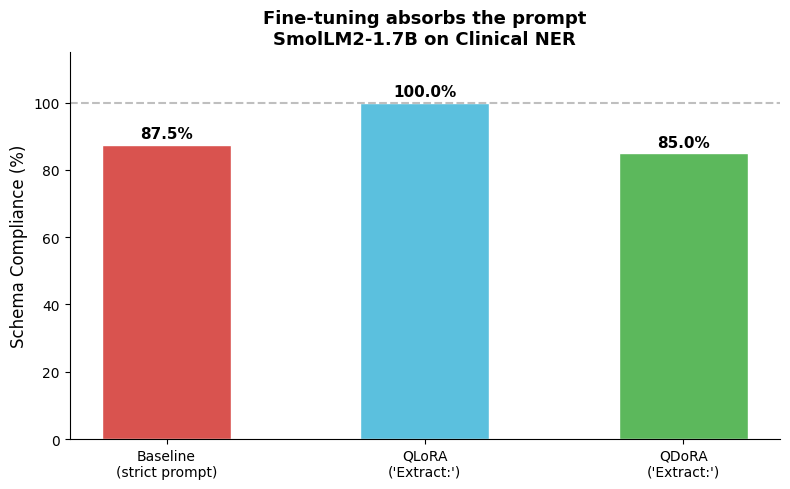

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

models = ["Baseline\n(strict prompt)",
          "QLoRA\n('Extract:')", "QDoRA\n('Extract:')"]
scores = [baseline_strict_score, qlora_score, qdora_score]
colors = ["#d9534f", "#5bc0de", "#5cb85c"]

bars = ax.bar(models, scores, color=colors, width=0.5, edgecolor="white")

# Annotate each bar with its value
for bar, score in zip(bars, scores):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{score:.1f}%",
        ha="center", va="bottom", fontsize=11, fontweight="bold"
    )

ax.set_ylim(0, 115)
ax.set_ylabel("Schema Compliance (%)", fontsize=12)
ax.set_title("Fine-tuning absorbs the prompt\nSmolLM2-1.7B on Clinical NER",
             fontsize=13, fontweight="bold")
ax.axhline(y=100, color="gray", linestyle="--", alpha=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("ch07_results.png", dpi=150, bbox_inches="tight")
plt.show()

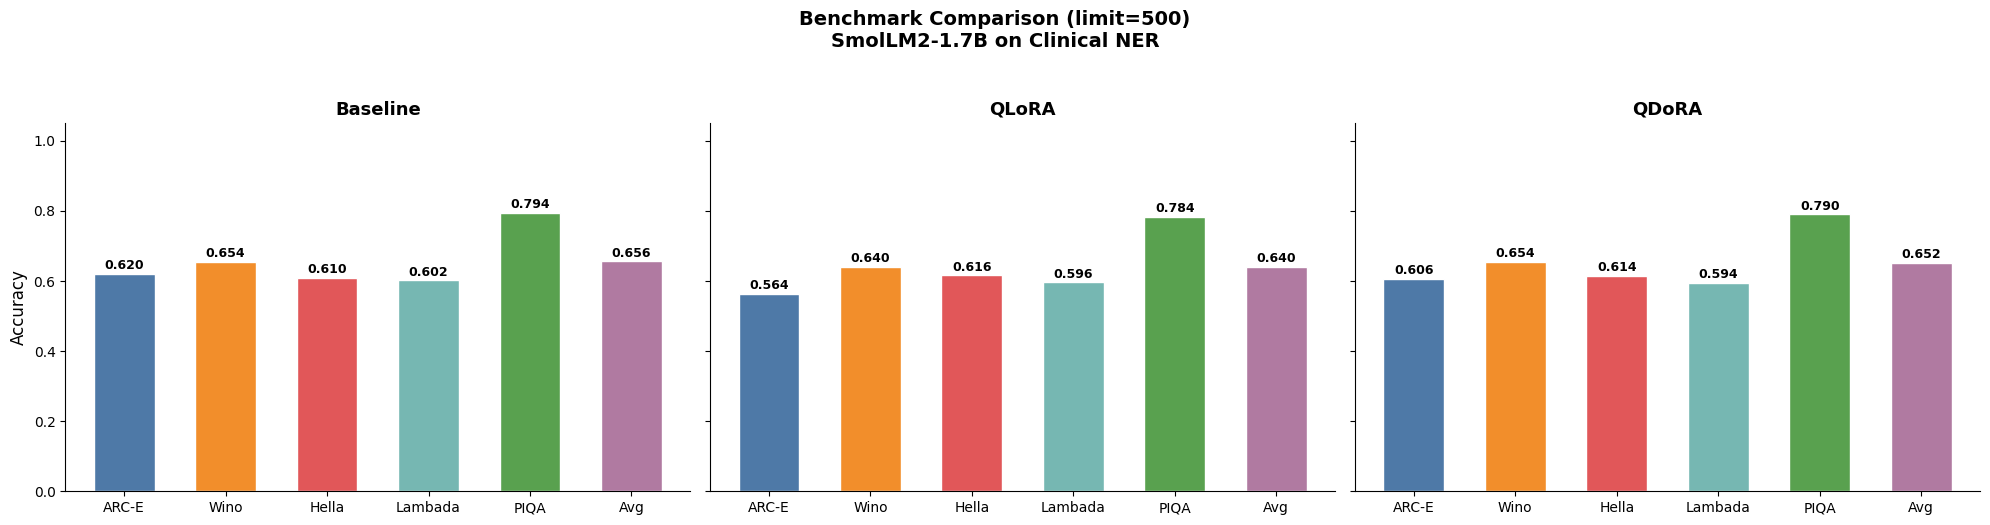

In [ ]:
if EXECUTE_BENCHMARKS:
    def extract_accuracy(bench_results, task_name):
        """Extract the best accuracy metric from model_evaluation results."""
        metrics = bench_results.get(task_name, {})
        for key in ["acc_norm", "accuracy"]:
            if key in metrics:
                return float(metrics[key])
        return 0.0

    fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)
    colors_bench = ["#4e79a7", "#f28e2b", "#e15759", "#76b7b2", "#59a14f", "#b07aa1"]
    short_names = ["ARC-E", "Wino", "Hella", "Lambada", "PIQA", "Avg"]

    all_benchmarks = {
        "Baseline": baseline_benchmarks,
        "QLoRA": qlora_benchmarks,
        "QDoRA": qdora_benchmarks,
    }

    for ax, (model_name, bench) in zip(axes, all_benchmarks.items()):
        scores = [extract_accuracy(bench, task) for task in BENCHMARK_TASKS]
        avg = sum(scores) / len(scores)
        scores_with_avg = scores + [avg]

        bars = ax.bar(short_names, scores_with_avg, color=colors_bench, width=0.6, edgecolor="white")

        for bar, score in zip(bars, scores_with_avg):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                    f"{score:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

        ax.set_ylim(0, 1.05)
        ax.set_title(model_name, fontsize=13, fontweight="bold")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[0].set_ylabel("Accuracy", fontsize=12)

    fig.suptitle(f"Benchmark Comparison (limit={BENCHMARK_LIMIT})\nSmolLM2-1.7B on Clinical NER",
                 fontsize=14, fontweight="bold", y=1.04)
    plt.tight_layout()
    plt.savefig("ch07_benchmarks.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Benchmark chart not available (EXECUTE_BENCHMARKS=False)")


| Modelo | Condición | Schema Compliance |
|---|---|---|
| Qwen3-1.7B | Baseline strict prompt | 100% |
| Qwen3-1.7B | Baseline minimal prompt | 0% |
| Qwen3-1.7B | QLoRA minimal prompt | 97.5% |
| Qwen3-1.7B | QDoRA minimal prompt | 95.0% |
| SmolLM2-1.7B | Baseline strict prompt | 87.5% |
| SmolLM2-1.7B | Baseline minimal prompt | 0% |
| SmolLM2-1.7B | QLoRA minimal prompt | 95.0% |
| SmolLM2-1.7B | QDoRA minimal prompt | 97.5% |
| Llama-3.2-1B | Baseline strict prompt | 87.5% |
| Llama-3.2-1B | QLoRA minimal prompt | 97.5% |
| Llama-3.2-1B | QDoRA minimal prompt | 97.5% |
| Llama-3.2-3B | Baseline strict prompt | 95.0% |
| Llama-3.2-3B | QLoRA minimal prompt | 77.5% |
| Llama-3.2-3B | QDoRA minimal prompt | 77.5% |

During the development of this chapter, we tested four model families to find the most honest experimental conditions. Qwen3-1.7B proved too capable as a baseline — its instruction-following strength meant the strict prompt already achieved 100% schema compliance, leaving no room to demonstrate improvement through fine-tuning. Llama-3.2-3B showed the opposite problem: despite a strong baseline at 95%, the fine-tuned models collapsed to 77.5% on noisy clinical notes, suggesting that a larger model generalizes poorly under data-scarce conditions. Both Llama-3.2-1B and SmolLM2-1.7B offered the most honest experimental conditions — a baseline that reflects realistic limitations and fine-tuned models that demonstrate clear, measurable improvement. We selected SmolLM2-1.7B as the chapter model because it represents a family not covered elsewhere in the book, broadening the reader's exposure to different open-source architectures.